# QPA Runtime Analysis — Unrolled Strategy (T=1) — IBM Pittsburgh

Companion to [`end_to_end_unrolled_pittsburgh_t1.ipynb`](end_to_end_unrolled_pittsburgh_t1.ipynb). While the full `N ∈ {3, 5, 7}` sweep runs, this notebook pulls **QPU usage** for the jobs that have already landed and breaks it down by parameter.

**Scope: `N = 3` only** (`K=2`, `T=1`) — the only `N` with both DD passes complete. Bump `N_VALUES` once `N=5, 7` finish.

In the main notebook, each `(N, λ, dd)` submission fans out into `n_batches` IBM jobs, and every job id is recorded (comma-separated) in the per-`(N, dd)` checkpoint CSV. Here we:

1. Read the `N=3` checkpoint CSVs (`dd_off`, `dd_on`) and expand `job_ids` into **one row per job**, tagged with its `(λ, dd, batch)` parameters.
2. Retrieve each job from `QiskitRuntimeService` and pull `job.metrics()`.
3. Extract **QPU time** (`usage.quantum_seconds` — the billed quantum seconds) plus queue / run wall-times.
4. Plot QPU time per job, categorized by `λ` and DD mode, and save a tidy `runtime_analysis` CSV.


In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.notebook import tqdm

from qiskit_ibm_runtime import QiskitRuntimeService

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

Mirrors the parameter block of the main notebook, but only the **completed** `N` values are listed. Everything is driven off the same `RESULTS_DIR` / checkpoint-filename convention so this notebook stays in sync automatically.

In [2]:
# ----- Experiment Parameters (must match end_to_end_unrolled_pittsburgh_t1.ipynb) -----
K = 2
T = 1
N_VALUES = [3]               # only N=3 is complete; extend to [3, 5, 7] once the rest finish
DD_MODES = ["off", "on"]
DEVICE = "ibm_pittsburgh"

RESULTS_DIR = os.path.join("data", "results", "end_to_end_unrolled_pittsburgh_t1")

def checkpoint_csv(n, dd_mode):
    '''Path of the per-(N, dd) checkpoint CSV written by the main notebook.'''
    base = f"results_n{n}_k{K}_t{T}_unrolled_ibm_pittsburgh_dd_{dd_mode}"
    return os.path.join(RESULTS_DIR, base + ".csv")

# Consistent colors for the two DD modes across every plot
DD_COLORS = {"off": "#4C72B0", "on": "#DD8452"}

print(f"Analyzing N={N_VALUES}, K={K}, T={T}, dd modes={DD_MODES}")
print(f"Results dir: {RESULTS_DIR}")

Analyzing N=[3], K=2, T=1, dd modes=['off', 'on']
Results dir: data/results/end_to_end_unrolled_pittsburgh_t1


## Step 2: Build the Job Table

Read each checkpoint CSV and explode the comma-separated `job_ids` column into one row per IBM job. The batch index is recovered from the position within the `job_ids` list (batch 0, 1, … in submission order).

In [3]:
job_rows = []
for n in N_VALUES:
    for dd_mode in DD_MODES:
        csv_path = checkpoint_csv(n, dd_mode)
        if not os.path.exists(csv_path):
            print(f"  [skip] no checkpoint for N={n}, dd={dd_mode}: {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        n_jobs_here = 0
        for _, row in df.iterrows():
            job_ids = [j for j in str(row["job_ids"]).split(",") if j]
            for batch_idx, job_id in enumerate(job_ids):
                job_rows.append({
                    "job_id": job_id,
                    "n": n, "k": K, "t": T,
                    "lambda": float(row["lambda"]),
                    "dd_mode": dd_mode,
                    "batch_idx": batch_idx,
                    "n_batches": int(row["n_batches"]),
                })
                n_jobs_here += 1
        print(f"  N={n}, dd={dd_mode}: {len(df)} lambda points -> {n_jobs_here} jobs")

jobs_df = pd.DataFrame(job_rows)
if jobs_df.empty:
    raise RuntimeError("No jobs found. Has the main notebook produced any N=3 checkpoints yet?")
print(f"\nTotal jobs to analyze: {len(jobs_df)}")
jobs_df.head()

  N=3, dd=off: 10 lambda points -> 20 jobs
  N=3, dd=on: 10 lambda points -> 20 jobs

Total jobs to analyze: 40


,job_id,n,k,t,lambda,dd_mode,batch_idx,n_batches
0,d82k657oha1c73blm9t0,3,2,1,0.0,off,0,2
1,d82k85egbeec73althng,3,2,1,0.0,off,1,2
2,d82k9amgbeec73altivg,3,2,1,0.1,off,0,2
3,d82kagugbeec73altkbg,3,2,1,0.1,off,1,2
4,d82kbmftjchs73bo6c30,3,2,1,0.2,off,0,2


## Step 3: Connect to IBM Quantum

In [4]:
service = QiskitRuntimeService()
print("Connected to QiskitRuntimeService.")

Connected to QiskitRuntimeService.


## Step 4: Inspect Raw Metrics for One Job

Before scraping all jobs, dump the full `job.metrics()` payload for the first job. The exact key holding QPU time can shift between `qiskit-ibm-runtime` versions — this confirms where it lives (expected: `usage.quantum_seconds`, with `bss.seconds` as a sibling).

In [5]:
sample_job_id = jobs_df.iloc[0]["job_id"]
sample_job = service.job(sample_job_id)
sample_metrics = sample_job.metrics()

print(f"job_id: {sample_job_id}")
print(f"status: {sample_job.status()}")
print("metrics():")
print(json.dumps(sample_metrics, indent=2, default=str))

job_id: d82k657oha1c73blm9t0
status: DONE
metrics():
{
  "caller": "qiskit_ibm_runtime~sampler.py",
  "qiskit_version": "qiskit_ibm_runtime-0.45.1,qiskit-2.3.0*,qiskit_aer-0.17.2",
  "timestamps": {
    "created": "2026-05-14T03:35:50.435802Z",
    "finished": "2026-05-14T03:39:52.881559Z",
    "running": "2026-05-14T03:37:46.651457Z"
  },
  "bss": {
    "seconds": 6
  },
  "usage": {
    "quantum_seconds": 6,
    "seconds": 6,
    "status": "complete"
  }
}


## Step 5: Pull Metrics for Every Job

`usage.quantum_seconds` is the billed QPU time; `extract_qpu_seconds` falls back to `bss.seconds` / `usage.seconds` for older runtime versions. Queue and run wall-times come from the `timestamps` block. Each fetch is wrapped in `try/except` so one bad job id doesn't sink the whole scrape.

In [6]:
def extract_qpu_seconds(metrics):
    '''Billed QPU time from a job.metrics() payload, with fallbacks across runtime versions.'''
    usage = metrics.get("usage", {}) or {}
    if usage.get("quantum_seconds") is not None:
        return float(usage["quantum_seconds"])
    bss = metrics.get("bss", {}) or {}
    if bss.get("seconds") is not None:
        return float(bss["seconds"])
    if usage.get("seconds") is not None:
        return float(usage["seconds"])
    return np.nan

def extract_timestamps(metrics):
    '''(created, running, finished) as tz-aware Timestamps; NaT where missing.'''
    ts = metrics.get("timestamps", {}) or {}
    created = pd.to_datetime(ts.get("created"), utc=True, errors="coerce")
    running = pd.to_datetime(ts.get("running"), utc=True, errors="coerce")
    finished = pd.to_datetime(ts.get("finished"), utc=True, errors="coerce")
    return created, running, finished

records = []
for row in tqdm(jobs_df.to_dict("records"), desc="Fetching job metrics"):
    rec = dict(row)
    try:
        job = service.job(row["job_id"])
        metrics = job.metrics()
        created, running, finished = extract_timestamps(metrics)
        rec["status"] = str(job.status())
        rec["qpu_seconds"] = extract_qpu_seconds(metrics)
        rec["executions"] = metrics.get("executions")
        rec["created"] = created
        rec["running"] = running
        rec["finished"] = finished
        rec["queue_seconds"] = ((running - created).total_seconds()
                                if pd.notna(running) and pd.notna(created) else np.nan)
        rec["run_seconds"] = ((finished - running).total_seconds()
                              if pd.notna(finished) and pd.notna(running) else np.nan)
    except Exception as e:
        rec["status"] = f"ERROR: {e}"
        rec["qpu_seconds"] = np.nan
        rec["executions"] = None
        rec["created"] = rec["running"] = rec["finished"] = pd.NaT
        rec["queue_seconds"] = rec["run_seconds"] = np.nan
        print(f"  [error] {row['job_id']}: {e}")
    records.append(rec)

runtime_df = pd.DataFrame(records).sort_values(
    ["dd_mode", "lambda", "batch_idx"]).reset_index(drop=True)
print(f"\nFetched QPU time for {runtime_df['qpu_seconds'].notna().sum()}/{len(runtime_df)} jobs.")
runtime_df

Fetching job metrics:   0%|          | 0/40 [00:00<?, ?it/s]


Fetched QPU time for 40/40 jobs.


,job_id,n,k,t,lambda,dd_mode,batch_idx,n_batches,status,qpu_seconds,executions,created,running,finished,queue_seconds,run_seconds
0,d82k657oha1c73blm9t0,3,2,1,0.0,off,0,2,DONE,6.0,None,2026-05-14 03:35:50.435802+00:00,2026-05-14 03:37:46.651457+00:00,2026-05-14 03:39:52.881559+00:00,116.215655,126.230102
1,d82k85egbeec73althng,3,2,1,0.0,off,1,2,DONE,6.0,None,2026-05-14 03:40:06.089734+00:00,2026-05-14 03:40:13.890566+00:00,2026-05-14 03:42:21.902067+00:00,7.800832,128.011501
2,d82k9amgbeec73altivg,3,2,1,0.1,off,0,2,DONE,6.0,None,2026-05-14 03:42:34.713320+00:00,2026-05-14 03:42:43.862389+00:00,2026-05-14 03:44:54.957107+00:00,9.149069,131.094718
3,d82kagugbeec73altkbg,3,2,1,0.1,off,1,2,DONE,6.0,None,2026-05-14 03:45:07.723612+00:00,2026-05-14 03:45:15.702488+00:00,2026-05-14 03:47:24.166215+00:00,7.978876,128.463727
4,d82kbmftjchs73bo6c30,3,2,1,0.2,off,0,2,DONE,6.0,None,2026-05-14 03:47:38.269477+00:00,2026-05-14 03:47:45.567581+00:00,2026-05-14 03:49:52.381666+00:00,7.298104,126.814085
5,d82kcr7oha1c73blmh10,3,2,1,0.2,off,1,2,DONE,6.0,None,2026-05-14 03:50:05.390381+00:00,2026-05-14 03:50:13.248408+00:00,2026-05-14 03:52:25.616814+00:00,7.858027,132.368406
6,d82ke1g0bvlc73d2dqrg,3,2,1,0.3,off,0,2,DONE,6.0,None,2026-05-14 03:52:39.365586+00:00,2026-05-14 03:52:47.734992+00:00,2026-05-14 03:54:54.624288+00:00,8.369406,126.889296
7,d82kf6ugbeec73altp7g,3,2,1,0.3,off,1,2,DONE,6.0,None,2026-05-14 03:55:07.982030+00:00,2026-05-14 03:55:29.694069+00:00,2026-05-14 03:57:41.218058+00:00,21.712039,131.523989
8,d82kggntjchs73bo6h1g,3,2,1,0.4,off,0,2,DONE,6.0,None,2026-05-14 03:57:54.976431+00:00,2026-05-14 03:58:01.515814+00:00,2026-05-14 04:00:13.381758+00:00,6.539383,131.865944
9,d82khmmgbeec73altsb0,3,2,1,0.4,off,1,2,DONE,6.0,None,2026-05-14 04:00:26.443882+00:00,2026-05-14 04:00:33.597211+00:00,2026-05-14 04:02:42.951321+00:00,7.153329,129.354110


## Step 6: Summary by Parameter

In [7]:
print("=== QPU seconds by DD mode ===")
print(runtime_df.groupby("dd_mode")["qpu_seconds"].agg(["count", "sum", "mean", "min", "max"]))

print("\n=== QPU seconds by lambda and DD mode (summed over batches) ===")
qpu_pivot = runtime_df.pivot_table(index="lambda", columns="dd_mode",
                                   values="qpu_seconds", aggfunc="sum")
print(qpu_pivot)

total_qpu = runtime_df["qpu_seconds"].sum()
print(f"\nTotal QPU time (N=3, all {len(runtime_df)} jobs): {total_qpu:.2f} quantum-seconds "
      f"({total_qpu/60:.2f} min)")

=== QPU seconds by DD mode ===
         count    sum  mean  min   max
dd_mode                               
off         20  130.0  6.50  6.0  14.0
on          20  173.0  8.65  8.0  15.0

=== QPU seconds by lambda and DD mode (summed over batches) ===
dd_mode   off    on
lambda             
0.0      12.0  23.0
0.1      12.0  16.0
0.2      12.0  16.0
0.3      12.0  16.0
0.4      12.0  18.0
0.5      12.0  16.0
0.6      12.0  16.0
0.7      12.0  19.0
0.8      12.0  17.0
0.9      22.0  16.0

Total QPU time (N=3, all 40 jobs): 303.00 quantum-seconds (5.05 min)


## Step 7: Plots

Three views of the same data:

1. **Per job** — QPU time of every individual job, grouped by DD mode then `λ` then batch. This is the raw "QPU time for each job" plot.
2. **Per λ point** — QPU time summed over batches, grouped bars for DD off vs on. The cleanest parameter-categorized view.
3. **QPU vs wall-time** — billed QPU seconds against run wall-time per job, to show how much of each job is per-job overhead vs actual quantum execution.

Saved: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_qpu_per_job_n3.png


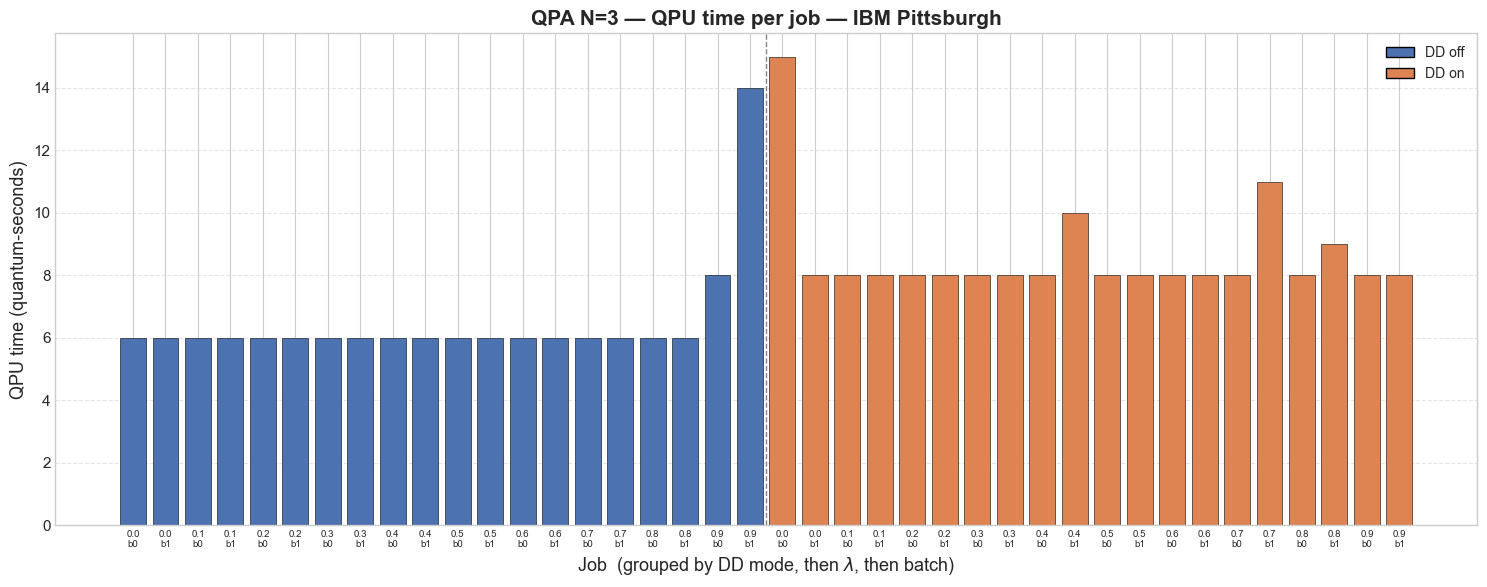

In [8]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 13, 'axes.titlesize': 15,
    'xtick.labelsize': 10, 'ytick.labelsize': 11, 'legend.fontsize': 10,
})

# ---- Plot 1: QPU time per job ----
fig, ax = plt.subplots(figsize=(15, 6))
plot_df = runtime_df.reset_index(drop=True)
x = np.arange(len(plot_df))
bar_colors = [DD_COLORS[dd] for dd in plot_df["dd_mode"]]
ax.bar(x, plot_df["qpu_seconds"], color=bar_colors, edgecolor="black", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['lambda']:.1f}\nb{r['batch_idx']}" for _, r in plot_df.iterrows()],
                   fontsize=7)
ax.set_xlabel(r"Job  (grouped by DD mode, then $\lambda$, then batch)")
ax.set_ylabel("QPU time (quantum-seconds)")
ax.set_title("QPA N=3 — QPU time per job — IBM Pittsburgh", fontweight="bold")

# Vertical divider + labels between the DD-off and DD-on groups
n_off = int((plot_df["dd_mode"] == "off").sum())
if 0 < n_off < len(plot_df):
    ax.axvline(n_off - 0.5, color="gray", linestyle="--", linewidth=1)
ax.legend(handles=[Patch(facecolor=DD_COLORS[m], edgecolor="black", label=f"DD {m}")
                   for m in DD_MODES])
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plot1_path = os.path.join(RESULTS_DIR, "runtime_qpu_per_job_n3.png")
plt.savefig(plot1_path, dpi=300, bbox_inches="tight")
print(f"Saved: {plot1_path}")
plt.show()

Saved: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_qpu_by_lambda_n3.png


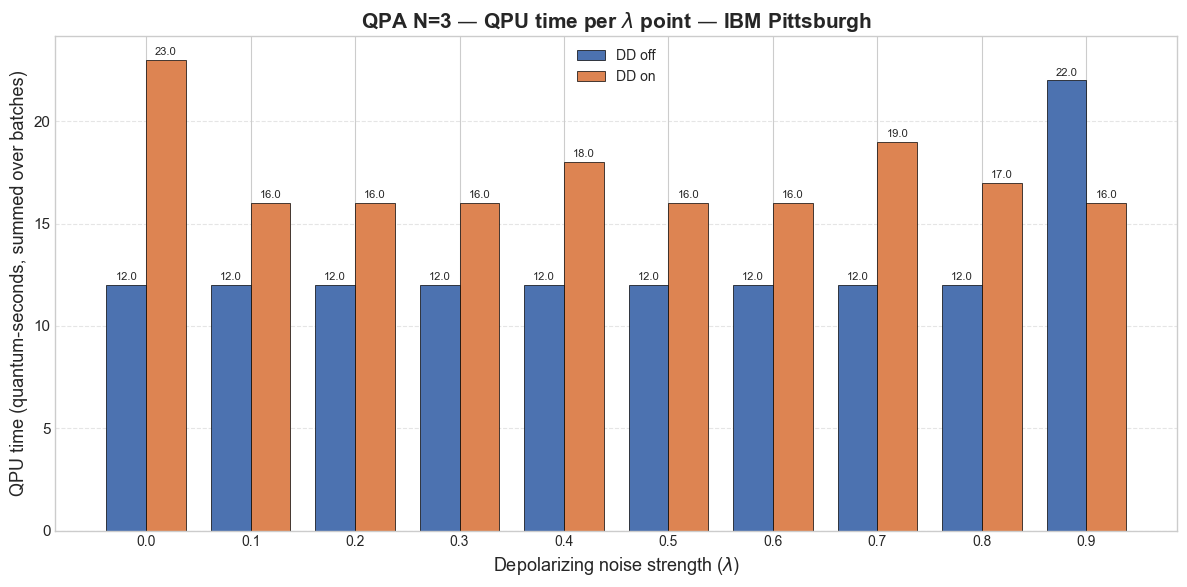

In [9]:
# ---- Plot 2: QPU time per lambda point, DD off vs on ----
fig, ax = plt.subplots(figsize=(12, 6))
lambdas = qpu_pivot.index.values
x = np.arange(len(lambdas))
width = 0.38
for i, dd_mode in enumerate(DD_MODES):
    if dd_mode in qpu_pivot.columns:
        offset = (i - (len(DD_MODES) - 1) / 2) * width
        bars = ax.bar(x + offset, qpu_pivot[dd_mode].values, width,
                      label=f"DD {dd_mode}", color=DD_COLORS[dd_mode],
                      edgecolor="black", linewidth=0.5)
        ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([f"{l:.1f}" for l in lambdas])
ax.set_xlabel(r"Depolarizing noise strength ($\lambda$)")
ax.set_ylabel("QPU time (quantum-seconds, summed over batches)")
ax.set_title("QPA N=3 — QPU time per $\\lambda$ point — IBM Pittsburgh", fontweight="bold")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plot2_path = os.path.join(RESULTS_DIR, "runtime_qpu_by_lambda_n3.png")
plt.savefig(plot2_path, dpi=300, bbox_inches="tight")
print(f"Saved: {plot2_path}")
plt.show()

Saved: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_qpu_vs_walltime_n3.png


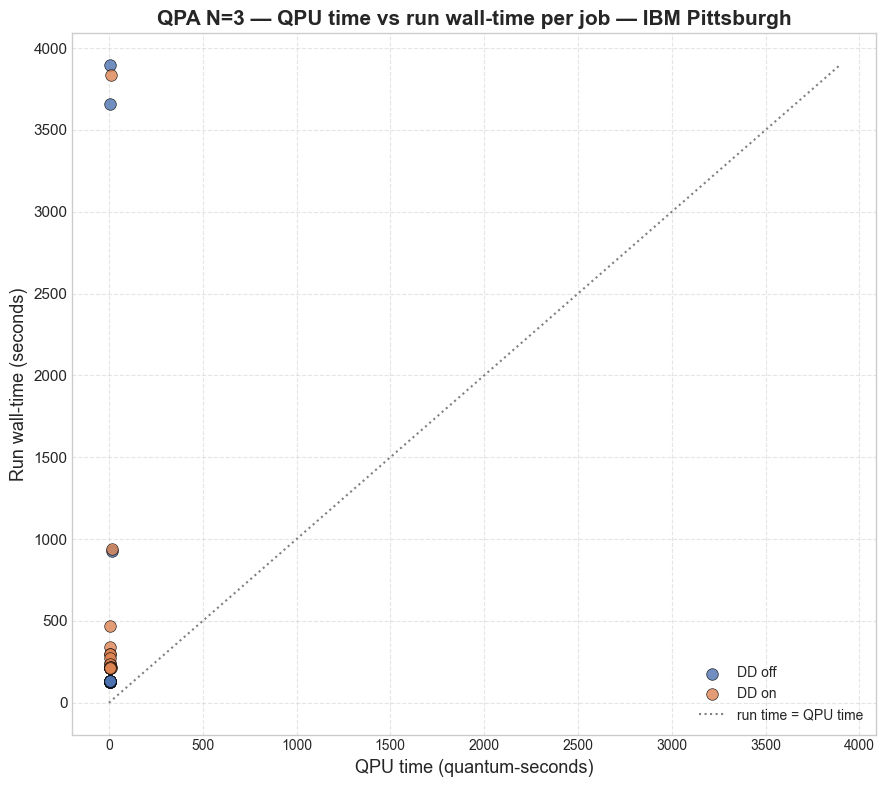

In [10]:
# ---- Plot 3: QPU time vs run wall-time per job ----
fig, ax = plt.subplots(figsize=(9, 8))
for dd_mode in DD_MODES:
    sub = runtime_df[runtime_df["dd_mode"] == dd_mode]
    ax.scatter(sub["qpu_seconds"], sub["run_seconds"],
               color=DD_COLORS[dd_mode], s=70, alpha=0.8,
               edgecolors="black", linewidth=0.5, label=f"DD {dd_mode}")

# y = x reference line (run time == pure QPU time, i.e. zero overhead)
both = runtime_df[["qpu_seconds", "run_seconds"]].dropna()
if not both.empty:
    hi = float(np.nanmax(both.values))
    ax.plot([0, hi], [0, hi], color="gray", linestyle=":", linewidth=1.5,
            label="run time = QPU time")

ax.set_xlabel("QPU time (quantum-seconds)")
ax.set_ylabel("Run wall-time (seconds)")
ax.set_title("QPA N=3 — QPU time vs run wall-time per job — IBM Pittsburgh",
             fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plot3_path = os.path.join(RESULTS_DIR, "runtime_qpu_vs_walltime_n3.png")
plt.savefig(plot3_path, dpi=300, bbox_inches="tight")
print(f"Saved: {plot3_path}")
plt.show()

## Step 8: Save the Runtime Table

Write the per-job runtime breakdown to CSV alongside the experiment results, so QPU-usage accounting doesn't require re-querying IBM.

In [11]:
out_csv = os.path.join(RESULTS_DIR, "runtime_analysis_n3_ibm_pittsburgh.csv")
runtime_df.to_csv(out_csv, index=False)
print(f"Runtime analysis saved to: {out_csv}")
print(f"  {len(runtime_df)} jobs, {runtime_df['qpu_seconds'].sum():.2f} total QPU-seconds")
runtime_df

Runtime analysis saved to: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_analysis_n3_ibm_pittsburgh.csv
  40 jobs, 303.00 total QPU-seconds


,job_id,n,k,t,lambda,dd_mode,batch_idx,n_batches,status,qpu_seconds,executions,created,running,finished,queue_seconds,run_seconds
0,d82k657oha1c73blm9t0,3,2,1,0.0,off,0,2,DONE,6.0,None,2026-05-14 03:35:50.435802+00:00,2026-05-14 03:37:46.651457+00:00,2026-05-14 03:39:52.881559+00:00,116.215655,126.230102
1,d82k85egbeec73althng,3,2,1,0.0,off,1,2,DONE,6.0,None,2026-05-14 03:40:06.089734+00:00,2026-05-14 03:40:13.890566+00:00,2026-05-14 03:42:21.902067+00:00,7.800832,128.011501
2,d82k9amgbeec73altivg,3,2,1,0.1,off,0,2,DONE,6.0,None,2026-05-14 03:42:34.713320+00:00,2026-05-14 03:42:43.862389+00:00,2026-05-14 03:44:54.957107+00:00,9.149069,131.094718
3,d82kagugbeec73altkbg,3,2,1,0.1,off,1,2,DONE,6.0,None,2026-05-14 03:45:07.723612+00:00,2026-05-14 03:45:15.702488+00:00,2026-05-14 03:47:24.166215+00:00,7.978876,128.463727
4,d82kbmftjchs73bo6c30,3,2,1,0.2,off,0,2,DONE,6.0,None,2026-05-14 03:47:38.269477+00:00,2026-05-14 03:47:45.567581+00:00,2026-05-14 03:49:52.381666+00:00,7.298104,126.814085
5,d82kcr7oha1c73blmh10,3,2,1,0.2,off,1,2,DONE,6.0,None,2026-05-14 03:50:05.390381+00:00,2026-05-14 03:50:13.248408+00:00,2026-05-14 03:52:25.616814+00:00,7.858027,132.368406
6,d82ke1g0bvlc73d2dqrg,3,2,1,0.3,off,0,2,DONE,6.0,None,2026-05-14 03:52:39.365586+00:00,2026-05-14 03:52:47.734992+00:00,2026-05-14 03:54:54.624288+00:00,8.369406,126.889296
7,d82kf6ugbeec73altp7g,3,2,1,0.3,off,1,2,DONE,6.0,None,2026-05-14 03:55:07.982030+00:00,2026-05-14 03:55:29.694069+00:00,2026-05-14 03:57:41.218058+00:00,21.712039,131.523989
8,d82kggntjchs73bo6h1g,3,2,1,0.4,off,0,2,DONE,6.0,None,2026-05-14 03:57:54.976431+00:00,2026-05-14 03:58:01.515814+00:00,2026-05-14 04:00:13.381758+00:00,6.539383,131.865944
9,d82khmmgbeec73altsb0,3,2,1,0.4,off,1,2,DONE,6.0,None,2026-05-14 04:00:26.443882+00:00,2026-05-14 04:00:33.597211+00:00,2026-05-14 04:02:42.951321+00:00,7.153329,129.354110


## Step 9: Total Time Comparison (including queue wait)

`total_seconds = queue_seconds + run_seconds` — the full wall-clock time from job submission to completion, i.e. **queue wait plus run time**. Steps 6–7 looked at billed QPU time; this section accounts for *everything* a job costs in calendar time.

Three views:

1. **Per λ point** — total time (queue + run, stacked), DD off vs on, summed over batches.
2. **Per job** — total time per individual job, queue/run stacked.
3. **Where the time goes** — all N=3 jobs decomposed into QPU compute / run overhead / queue wait, per DD mode.

The updated `runtime_df` (now with `total_seconds`) is re-saved at the end so the CSV on disk carries the column.

In [12]:
runtime_df["total_seconds"] = runtime_df["queue_seconds"] + runtime_df["run_seconds"]

print("=== Time by DD mode (seconds) ===")
print(runtime_df.groupby("dd_mode")[["queue_seconds", "run_seconds", "total_seconds", "qpu_seconds"]]
      .agg(["sum", "mean"]))

grand_total = runtime_df["total_seconds"].sum()
queue_total = runtime_df["queue_seconds"].sum()
run_total = runtime_df["run_seconds"].sum()
print(f"\nGrand total wall time (N=3, all {len(runtime_df)} jobs): "
      f"{grand_total:.1f} s ({grand_total / 60:.1f} min)")
if grand_total > 0:
    print(f"  queue wait: {queue_total:.1f} s ({100 * queue_total / grand_total:.1f}%)")
    print(f"  run time:   {run_total:.1f} s ({100 * run_total / grand_total:.1f}%)")

=== Time by DD mode (seconds) ===
        queue_seconds               run_seconds             total_seconds  \
                  sum        mean           sum        mean           sum   
dd_mode                                                                     
off       2236.236873  111.811844  10688.267206  534.413360  12924.504079   
on        2295.008574  114.750429   9278.547413  463.927371  11573.555987   

                    qpu_seconds        
               mean         sum  mean  
dd_mode                                
off      646.225204       130.0  6.50  
on       578.677799       173.0  8.65  

Grand total wall time (N=3, all 40 jobs): 24498.1 s (408.3 min)
  queue wait: 4531.2 s (18.5%)
  run time:   19966.8 s (81.5%)


Saved: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_total_by_lambda_n3.png


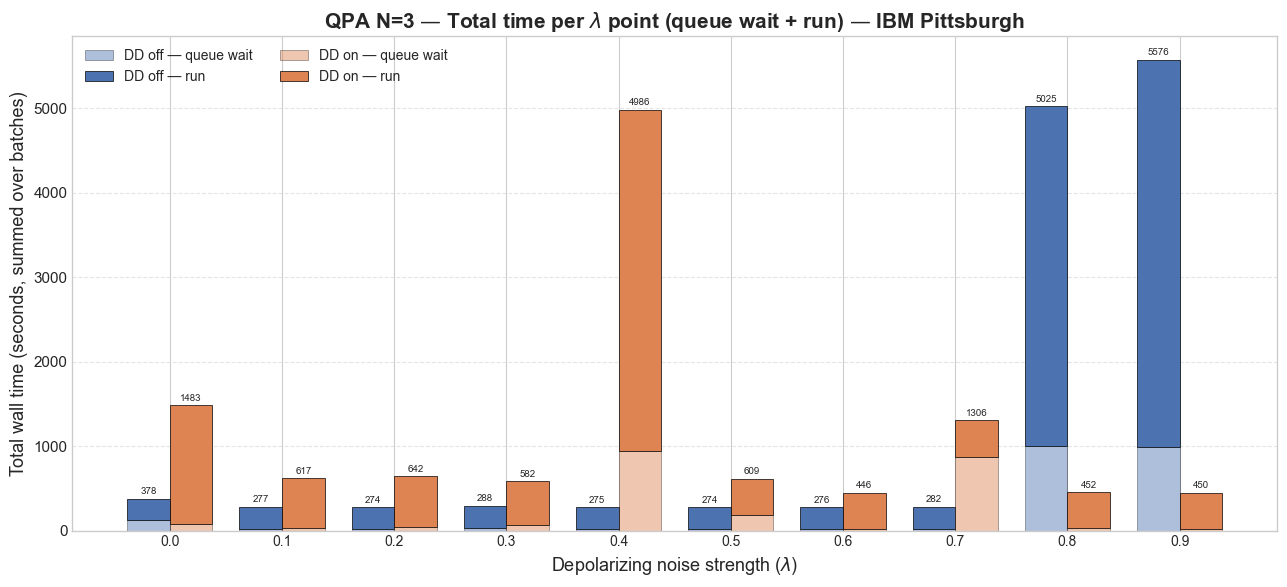

In [13]:
# ---- Plot 4: Total time per lambda point (queue + run stacked), DD off vs on ----
fig, ax = plt.subplots(figsize=(13, 6))
queue_pivot = runtime_df.pivot_table(index="lambda", columns="dd_mode",
                                     values="queue_seconds", aggfunc="sum")
run_pivot = runtime_df.pivot_table(index="lambda", columns="dd_mode",
                                   values="run_seconds", aggfunc="sum")
lambdas = queue_pivot.index.values
x = np.arange(len(lambdas))
width = 0.38
for i, dd_mode in enumerate(DD_MODES):
    if dd_mode not in queue_pivot.columns:
        continue
    offset = (i - (len(DD_MODES) - 1) / 2) * width
    q = queue_pivot[dd_mode].values
    r = run_pivot[dd_mode].values
    ax.bar(x + offset, q, width, color=DD_COLORS[dd_mode], alpha=0.45,
           edgecolor="black", linewidth=0.5, label=f"DD {dd_mode} — queue wait")
    bars = ax.bar(x + offset, r, width, bottom=q, color=DD_COLORS[dd_mode],
                  edgecolor="black", linewidth=0.5, label=f"DD {dd_mode} — run")
    ax.bar_label(bars, labels=[f"{t:.0f}" for t in (q + r)], fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels([f"{l:.1f}" for l in lambdas])
ax.set_xlabel(r"Depolarizing noise strength ($\lambda$)")
ax.set_ylabel("Total wall time (seconds, summed over batches)")
ax.set_title("QPA N=3 — Total time per $\\lambda$ point (queue wait + run) — IBM Pittsburgh",
             fontweight="bold")
ax.legend(ncol=2)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plot4_path = os.path.join(RESULTS_DIR, "runtime_total_by_lambda_n3.png")
plt.savefig(plot4_path, dpi=300, bbox_inches="tight")
print(f"Saved: {plot4_path}")
plt.show()

Saved: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_total_per_job_n3.png


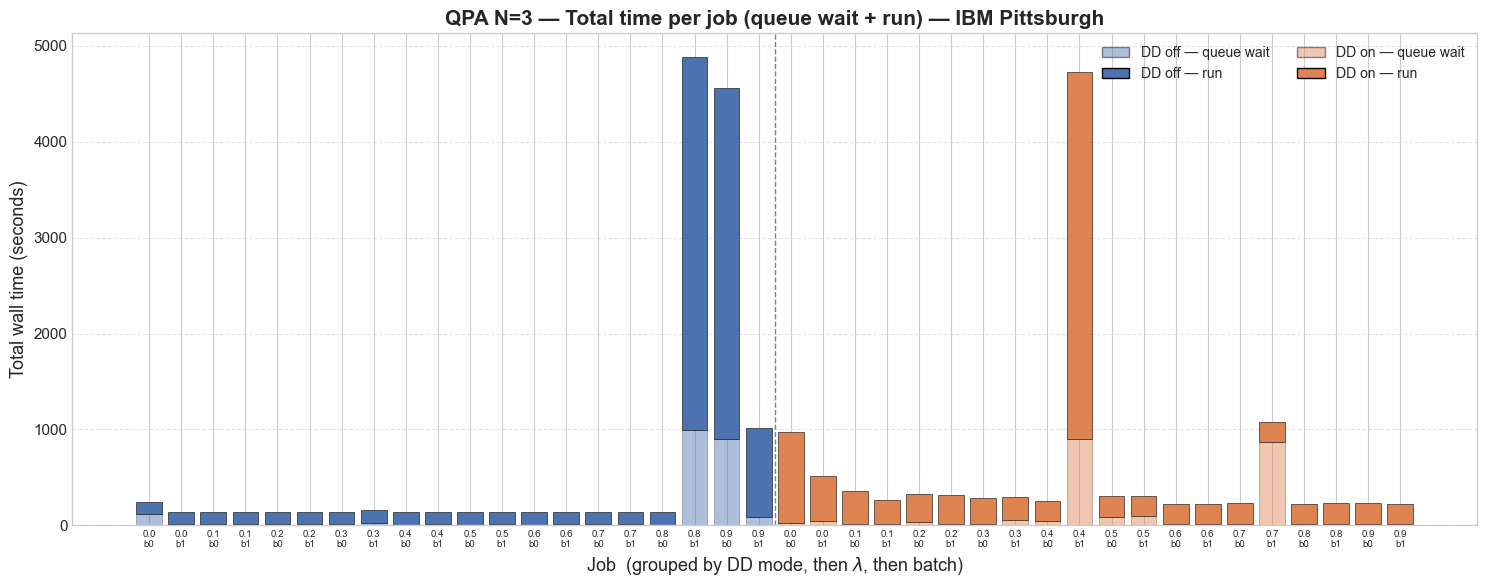

In [14]:
# ---- Plot 5: Total time per job (queue + run stacked) ----
fig, ax = plt.subplots(figsize=(15, 6))
plot_df = runtime_df.reset_index(drop=True)
x = np.arange(len(plot_df))
q = plot_df["queue_seconds"].values
r = plot_df["run_seconds"].values
base_colors = [DD_COLORS[dd] for dd in plot_df["dd_mode"]]

ax.bar(x, q, color=base_colors, alpha=0.45, edgecolor="black", linewidth=0.4)
ax.bar(x, r, bottom=q, color=base_colors, edgecolor="black", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([f"{row['lambda']:.1f}\nb{row['batch_idx']}"
                    for _, row in plot_df.iterrows()], fontsize=7)
ax.set_xlabel(r"Job  (grouped by DD mode, then $\lambda$, then batch)")
ax.set_ylabel("Total wall time (seconds)")
ax.set_title("QPA N=3 — Total time per job (queue wait + run) — IBM Pittsburgh",
             fontweight="bold")

n_off = int((plot_df["dd_mode"] == "off").sum())
if 0 < n_off < len(plot_df):
    ax.axvline(n_off - 0.5, color="gray", linestyle="--", linewidth=1)

legend_handles = []
for m in DD_MODES:
    legend_handles.append(Patch(facecolor=DD_COLORS[m], alpha=0.45, edgecolor="black",
                                label=f"DD {m} — queue wait"))
    legend_handles.append(Patch(facecolor=DD_COLORS[m], edgecolor="black",
                                label=f"DD {m} — run"))
ax.legend(handles=legend_handles, ncol=2)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plot5_path = os.path.join(RESULTS_DIR, "runtime_total_per_job_n3.png")
plt.savefig(plot5_path, dpi=300, bbox_inches="tight")
print(f"Saved: {plot5_path}")
plt.show()

Saved: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_time_breakdown_n3.png


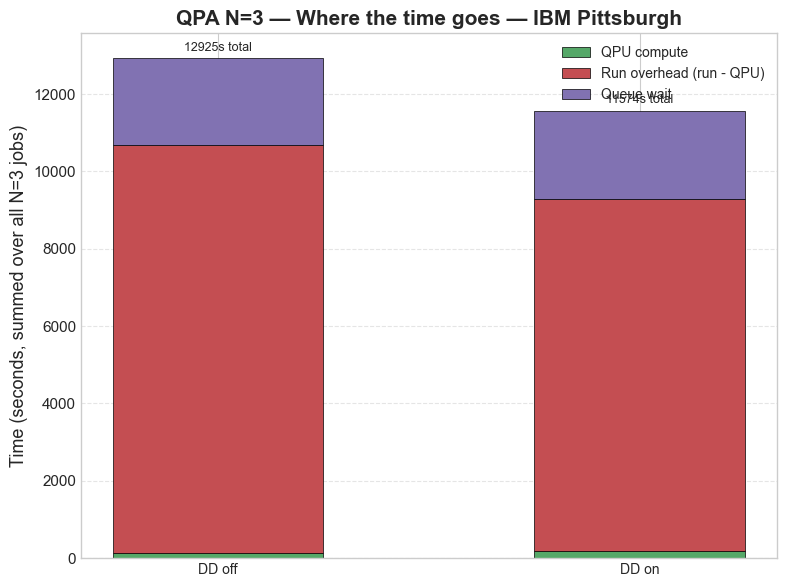

In [15]:
# ---- Plot 6: Where the time goes — QPU compute vs run overhead vs queue wait ----
fig, ax = plt.subplots(figsize=(8, 6))
breakdown = runtime_df.groupby("dd_mode").agg(
    qpu=("qpu_seconds", "sum"),
    run=("run_seconds", "sum"),
    queue=("queue_seconds", "sum"),
)
breakdown["run_overhead"] = (breakdown["run"] - breakdown["qpu"]).clip(lower=0)

modes = list(breakdown.index)
x = np.arange(len(modes))
qpu = breakdown["qpu"].values
overhead = breakdown["run_overhead"].values
queue = breakdown["queue"].values

ax.bar(x, qpu, 0.5, label="QPU compute", color="#55A868",
       edgecolor="black", linewidth=0.5)
ax.bar(x, overhead, 0.5, bottom=qpu, label="Run overhead (run - QPU)",
       color="#C44E52", edgecolor="black", linewidth=0.5)
b3 = ax.bar(x, queue, 0.5, bottom=qpu + overhead, label="Queue wait",
            color="#8172B2", edgecolor="black", linewidth=0.5)
totals = qpu + overhead + queue
ax.bar_label(b3, labels=[f"{t:.0f}s total" for t in totals], padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"DD {m}" for m in modes])
ax.set_ylabel("Time (seconds, summed over all N=3 jobs)")
ax.set_title("QPA N=3 — Where the time goes — IBM Pittsburgh", fontweight="bold")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plot6_path = os.path.join(RESULTS_DIR, "runtime_time_breakdown_n3.png")
plt.savefig(plot6_path, dpi=300, bbox_inches="tight")
print(f"Saved: {plot6_path}")
plt.show()

In [16]:
# Re-save the runtime table, now including the total_seconds column
out_csv = os.path.join(RESULTS_DIR, "runtime_analysis_n3_ibm_pittsburgh.csv")
runtime_df.to_csv(out_csv, index=False)
print(f"Runtime table (incl. total_seconds) re-saved to: {out_csv}")
runtime_df[["job_id", "dd_mode", "lambda", "batch_idx",
            "qpu_seconds", "queue_seconds", "run_seconds", "total_seconds"]]

Runtime table (incl. total_seconds) re-saved to: data/results/end_to_end_unrolled_pittsburgh_t1/runtime_analysis_n3_ibm_pittsburgh.csv


,job_id,dd_mode,lambda,batch_idx,qpu_seconds,queue_seconds,run_seconds,total_seconds
0,d82k657oha1c73blm9t0,off,0.0,0,6.0,116.215655,126.230102,242.445757
1,d82k85egbeec73althng,off,0.0,1,6.0,7.800832,128.011501,135.812333
2,d82k9amgbeec73altivg,off,0.1,0,6.0,9.149069,131.094718,140.243787
3,d82kagugbeec73altkbg,off,0.1,1,6.0,7.978876,128.463727,136.442603
4,d82kbmftjchs73bo6c30,off,0.2,0,6.0,7.298104,126.814085,134.112189
5,d82kcr7oha1c73blmh10,off,0.2,1,6.0,7.858027,132.368406,140.226433
6,d82ke1g0bvlc73d2dqrg,off,0.3,0,6.0,8.369406,126.889296,135.258702
7,d82kf6ugbeec73altp7g,off,0.3,1,6.0,21.712039,131.523989,153.236028
8,d82kggntjchs73bo6h1g,off,0.4,0,6.0,6.539383,131.865944,138.405327
9,d82khmmgbeec73altsb0,off,0.4,1,6.0,7.153329,129.354110,136.507439
